<a href="https://colab.research.google.com/github/httperror505/Neural-Network/blob/main/Naive_Bayesian_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas
!pip install scikit-learn
!pip install imbalanced-learn


In [ ]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from collections import Counter

# Load the CSV data file
student_dataset = pd.read_csv("/content/drive/MyDrive/New Student Performance Data Cleaned 2.csv")  # Adjust the path accordingly

# Check the first few rows of the data
print("Initial Dataset Head:")
print(student_dataset.head())

# Encode categorical variables
number = LabelEncoder()
categorical_columns = ['Absences', 'StudyTimeWeeklyCategory', 'Previous Grades']
for column in categorical_columns:
    student_dataset[column] = number.fit_transform(student_dataset[column])

# Define feature columns and target variable
features = ['Age', 'Gender', 'ParentalEducation', 'StudyTimeWeeklyCategory', 'Absences', 'Tutoring', 'ParentalSupport',
            'ExtracurricularCategory', 'Previous Grades', 'Year Level', 'Subject']
target = 'GradeCategory'

# Standardize numerical features for Gaussian Naive Bayes
scaler = StandardScaler()
student_dataset[features] = scaler.fit_transform(student_dataset[features])

# Split the data into training and testing sets (70% training, 30% testing)
features_train, features_test, target_train, target_test = train_test_split(
    student_dataset[features], student_dataset[target], test_size=0.30, random_state=62, stratify=student_dataset[target]
)

# Check the class distribution in the training data
print(f"Class distribution in training data: {Counter(target_train)}")

# Initialize Gaussian Naive Bayes model
model = GaussianNB()

# Train the model with training data
model.fit(features_train, target_train)

# Perform cross-validation for better accuracy estimation
cross_val_accuracies = cross_val_score(model, student_dataset[features], student_dataset[target], cv=5)
print(f"Cross-Validation Accuracies: {cross_val_accuracies}")
print(f"Mean Cross-Validation Accuracy: {cross_val_accuracies.mean() * 100:.2f}%")

# Make predictions on the test data
pred = model.predict(features_test)

# Calculate accuracy on test data
accuracy = accuracy_score(target_test, pred)
print(f"Test Set Accuracy: {accuracy * 100:.2f}%")

# 'Age', 'Gender', 'ParentalEducation', 'StudyTimeWeeklyCategory', 'Absences', 'Tutoring', 'ParentalSupport',
       # 'ExtracurricularCategory', 'Previous Grades', 'Year Level', 'Subject'
# Sample prediction with a new standardized sample
new_sample = scaler.transform([[17, 1, 4, 2, 0, 1, 4, 1, 4.0, 4, 1]])
# new_sample = scaler.transform([[17, 1, 2, 2, 7, 1, 2, 0, 3.470150708, 4, 3]])
predicted_class = model.predict(new_sample)

# Interpret the prediction
grade_classes = {
    0: 'A (GPA >= 3.5)',
    1: 'B (3.0 <= GPA < 3.5)',
    2: 'C (2.5 <= GPA < 3.0)',
    3: 'D (2.0 <= GPA < 2.5)',
    4: 'F (GPA < 2.0)'
}
print(f"\nPredicted GradeClass: {grade_classes[predicted_class[0]]} : {predicted_class}")

# Confusion Matrix
conf_matrix = confusion_matrix(target_test, pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report (Precision, Recall, F1-score for each class)
print("\nClassification Report:")
print(classification_report(target_test, pred, target_names=grade_classes.values()))

# Calculate precision, recall, and F1 score for each class (macro, weighted, etc.)
precision = precision_score(target_test, pred, average='weighted')
recall = recall_score(target_test, pred, average='weighted')
f1 = f1_score(target_test, pred, average='weighted')

print(f"\nOverall Metrics:")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")
print(f"F1 Score (Weighted): {f1:.2f}")

Initial Dataset Head:
   StudentID  Age  Gender  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1                  2        19.833723   
1       1002   18       0                  1        15.408756   
2       1003   15       0                  3         4.210570   
3       1004   17       1                  3        10.028829   
4       1005   17       1                  2         4.672495   

   StudyTimeWeeklyCategory  Absences  AbsencesCategory  Tutoring  \
0                        2         7                 1         1   
1                        0         0                 0         0   
2                        1        26                 2         0   
3                        0        14                 2         0   
4                        1        17                 2         1   

   ParentalSupport  ...  Sports  Music  Volunteering  Year Level       GPA  \
0                2  ...       0      1             0           1  3.189730   
1                1  ..

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

# Will be the filename of the trained model
filename = 'capstone_ai.pkl'

# Save the model
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved as {filename}")


Model saved as capstone_ai.pkl


In [ ]:
from google.colab import files

# Download the model file
files.download('capstone_ai.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

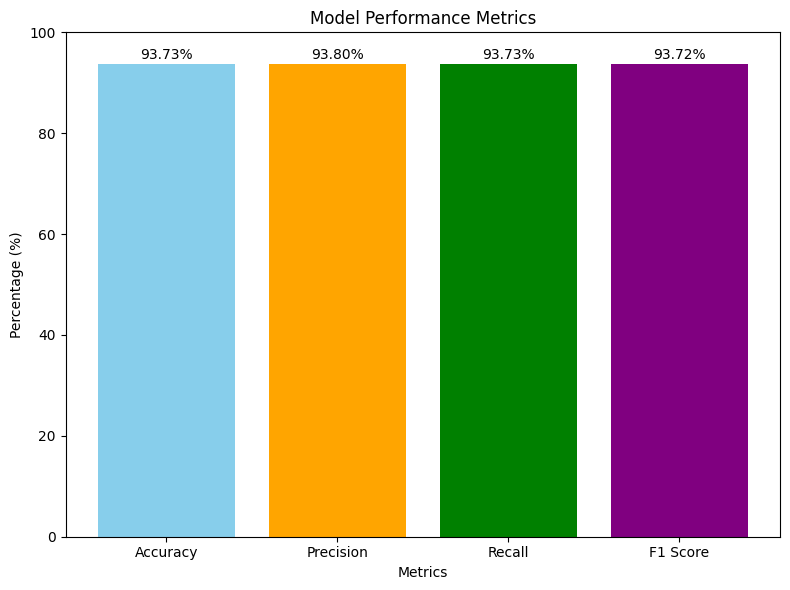

200 {
  "file_path": "uploads/plot.png",
  "message": "File uploaded successfully"
}



In [ ]:
import matplotlib.pyplot as plt
import io
import requests

# Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['skyblue', 'orange', 'green', 'purple'])

# Add labels and title
plt.ylabel('Percentage (%)')
plt.xlabel('Metrics')
plt.title('Model Performance Metrics')
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

# Save the plot to a BytesIO object
buffer = io.BytesIO()
plt.savefig(buffer, format='png')
buffer.seek(0)  # Rewind the buffer
plt.close()

# Send the plot to Flask backend
url = 'https://student-performance-ai-model-1.onrender.com/upload_plot'  # Replace with your Flask backend URL
files = {'file': ('plot.png', buffer, 'image/png')}
response = requests.post(url, files=files)

print(response.status_code, response.text)



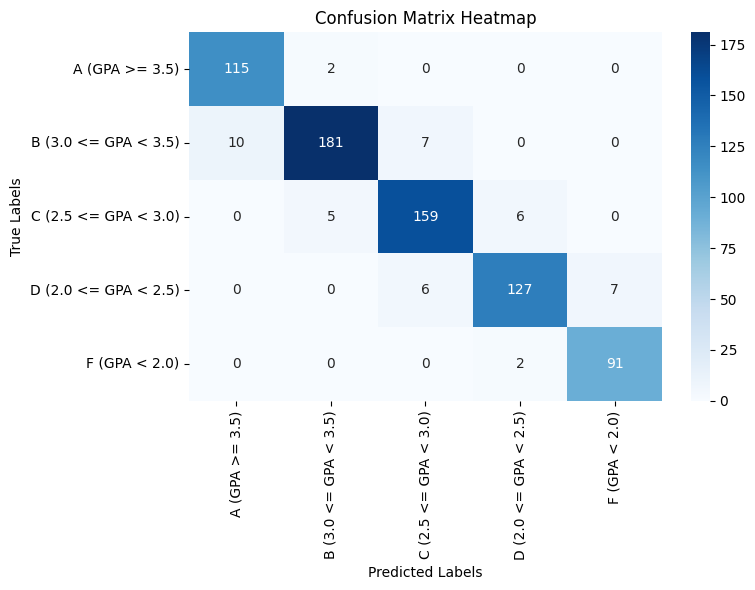

In [ ]:
import seaborn as sns
import numpy as np

# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=grade_classes.values(), yticklabels=grade_classes.values())

# Labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')

# Show the plot
plt.tight_layout()
plt.show()
